In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

slope: 1.88, intercept: 5.13


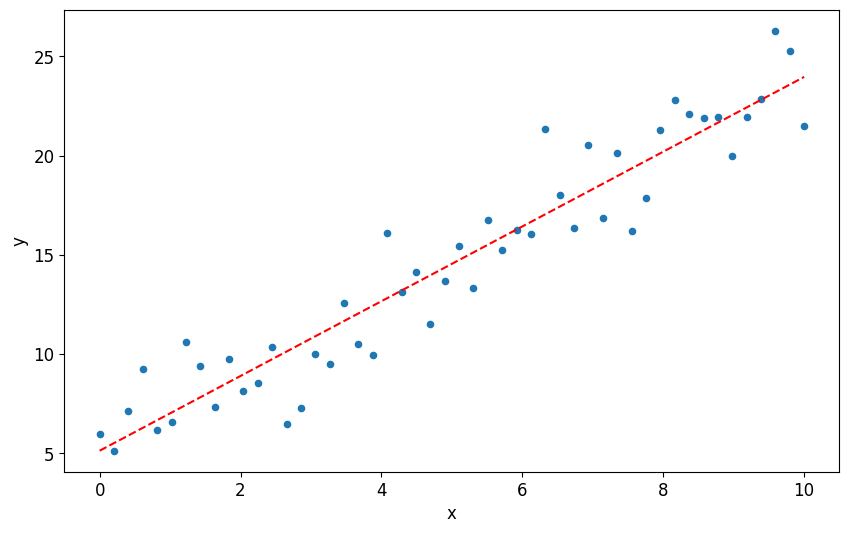

In [2]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

In [3]:
def fit_and_plot(x, y, ax):
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
  print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
  print(f"r: {r_value}")
  print(f"err: {std_err}")
  ax.plot(x, y, 'bo')
  x_linspace = np.linspace(min(x), max(x), 30)
  y_linreg = slope*x_linspace + intercept
  ax.plot(x_linspace, y_linreg, 'r-')

In [4]:
np.savetxt("dane_do_fit.txt", np.c_[x, y])

In [5]:
df = pd.read_csv("dane_do_fit.txt", delimiter=" ", header=None, names=["x", "y"])

In [6]:
df.head()

,x,y
0,0.000000,5.993428
1,0.204082,5.131635
2,0.408163,7.111704
3,0.612245,9.270550
4,0.816327,6.164346


slope: 1.88, intercept: 5.13
r: 0.9503548762459013
err: 0.08903837899142658


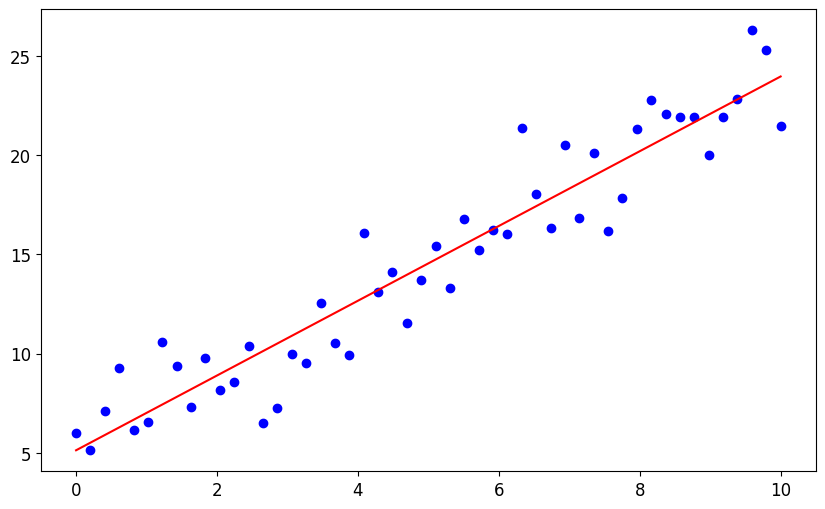

In [7]:
fig, ax = plt.subplots()
fit_and_plot(df['x'], df['y'], ax)

## Zadanie 1

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.





In [8]:
! head anscombe.csv

head: cannot open 'anscombe.csv' for reading: No such file or directory


Przekształcone dane:


,x1,y1,x2,y2,x3,y3,x4,y4
0,10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
1,8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
2,13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
3,9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
4,11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47


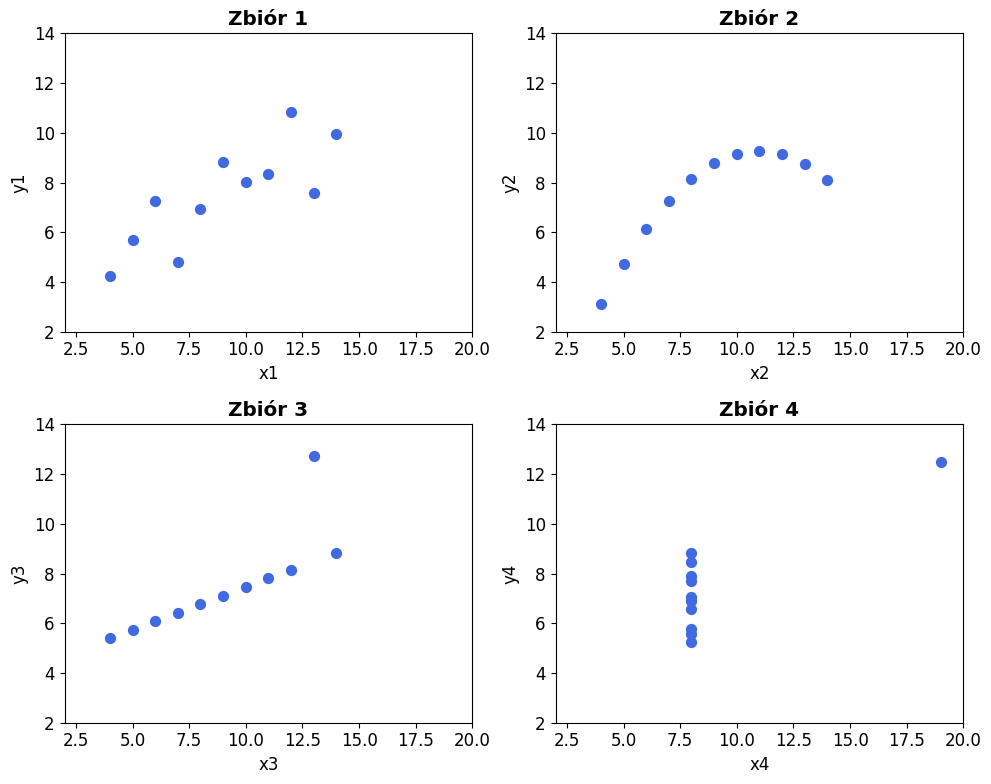

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Używamy wbudowanego zbioru Anscombe z Seaborn
df = sns.load_dataset("anscombe")

# Przekształcenie danych
df_I = df[df['dataset'] == 'I'].reset_index(drop=True)
df_II = df[df['dataset'] == 'II'].reset_index(drop=True)
df_III = df[df['dataset'] == 'III'].reset_index(drop=True)
df_IV = df[df['dataset'] == 'IV'].reset_index(drop=True)

df_wide = pd.DataFrame({
    'x1': df_I['x'], 'y1': df_I['y'],
    'x2': df_II['x'], 'y2': df_II['y'],
    'x3': df_III['x'], 'y3': df_III['y'],
    'x4': df_IV['x'], 'y4': df_IV['y']
})

print("Przekształcone dane:")
display(df_wide.head())

# Tworzymy siatkę wykresów 2x2
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i in range(1, 5):
    x_col = f'x{i}'
    y_col = f'y{i}'

    axs[i-1].scatter(df_wide[x_col], df_wide[y_col], color='royalblue', s=50)
    axs[i-1].set_title(f'Zbiór {i}', fontweight='bold')
    axs[i-1].set_xlabel(x_col)
    axs[i-1].set_ylabel(y_col)
    axs[i-1].set_xlim(2, 20)
    axs[i-1].set_ylim(2, 14)

plt.tight_layout()
plt.show()

## Zadanie 2

Przeprowadź eksploracyjną analizę danych (EDA) dla zbioru danych o domach `house_train.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df_house = pd.read_csv('house_train.csv')

print("1) PODSTAWOWE INFO I KSZTAŁT ZBIORU")
print(f"Liczba wierszy (domów): {df_house.shape[0]}")
print(f"Liczba kolumn (cech): {df_house.shape[1]}\n")
display(df_house.head())


print(" 2) ANALIZA BRAKÓW DANYCH (TOP 10)")
braki = df_house.isnull().sum()
braki = braki[braki > 0].sort_values(ascending=False)
if len(braki) > 0:
    print(braki.head(10))
else:
    print("Brak brakujących danych! Czysta tabela.")

print(" 3) WIZUALIZACJA (Rozkład cen i korelacje)")

target_col = 'SalePrice' if 'SalePrice' in df_house.columns else df_house.select_dtypes(include='number').columns[-1]
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_house[target_col], kde=True, bins=50, color='royalblue', ax=ax[0])
ax[0].set_title(f'Rozkład zmiennej: {target_col}', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Cena')
ax[0].set_ylabel('Liczba domów')

# WYKRES B: Heatmapa korelacji (co najbardziej wpływa na cenę?)
# Wybieramy tylko liczby i liczymy korelacje
num_cols = df_house.select_dtypes(include=['number'])
corr = num_cols.corr()

# Wybieramy tylko te cechy, które mocno wpływają na cenę (korelacja > 0.5 lub < -0.5)
silne_korelacje = corr.index[abs(corr[target_col]) > 0.5]

# Rysujemy heatmapę (mapę cieplną)
sns.heatmap(df_house[silne_korelacje].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1])
ax[1].set_title('Co najbardziej wpływa na cenę? (Heatmapa)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()